**Q1 The Income Trap**

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [53]:
pip install ucimlrepo

**Question 1:**

এটি মূলত Distributional Problem, শুধুমাত্র Outlier Problem নয়।

কারণ:

Normal Distribution-এ data সাধারণত bell-shaped হয় এবং mean-এর চারপাশে সমানভাবে ছড়িয়ে থাকে। কিন্তু capital-gain কলামে দেখা যায়:

প্রায় 91% observation-এর মান 0।
অল্প কিছু observation-এর মান অত্যন্ত বড় (কয়েক হাজার থেকে 99,000+ পর্যন্ত)।
Data অত্যন্ত right-skewed এবং zero-inflated।

ফলে এই distribution Normal Distribution অনুসরণ করে না।

**Question 2:**

capital-gain কলামে কিছু মান খুব বড় হওয়ায় StandardScaler ব্যবহার করলে সেগুলোর Z-score অনেক বেশি হবে। কারণ StandardScaler mean ও standard deviation-এর উপর নির্ভর করে, যা outlier দ্বারা প্রভাবিত হয়। তাই RobustScaler বেশি উপযুক্ত, কারণ এটি median ও IQR ব্যবহার করে এবং outlier-এর প্রভাব কম থাকে।

**Question 3:**

Winsorization হলো extreme values-কে নির্দিষ্ট percentile-এর মান দিয়ে replace করা।
5th–95th percentile Winsorization করলে ধরে নেওয়া হয় যে খুব কম বা খুব বেশি hours-per-week মানগুলো অস্বাভাবিক (outlier)।
ঝুঁকি হলো, যদি এই extreme values বাস্তব ও গুরুত্বপূর্ণ হয়, তাহলে গুরুত্বপূর্ণ তথ্য হারিয়ে যেতে পারে এবং data-এর variability কমে যেতে পারে।

In [54]:
# Question 04:

from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [55]:
X

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States


In [56]:
y

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K
...,...
48837,<=50K.
48838,<=50K.
48839,<=50K.
48840,<=50K.


In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("X train: ", X_train.shape)
print("X test: ", X_test.shape)

X train:  (39073, 14)
X test:  (9769, 14)


In [58]:
X_train.sample(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
48100,39,Self-emp-inc,142149,Assoc-acdm,12,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,20,United-States
36192,28,Private,167789,HS-grad,9,Never-married,Sales,Not-in-family,White,Female,0,0,60,United-States
27050,27,State-gov,271328,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,60,United-States
33969,41,Self-emp-not-inc,239061,Masters,14,Widowed,Prof-specialty,Not-in-family,White,Female,0,0,20,United-States
10217,49,Private,133729,Some-college,10,Married-civ-spouse,Other-service,Husband,White,Male,0,0,17,United-States


In [59]:
X_train.isnull().sum()

,0
age,0
workclass,772
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,774
relationship,0
race,0
sex,0


In [60]:
workclass_emputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

workclass_emputer.fit(X_train[['workclass']])
X_train['workclass'] = workclass_emputer.transform(X_train[['workclass']]).ravel()
X_test['workclass'] = workclass_emputer.transform(X_test[['workclass']]).ravel()

In [61]:
occupation_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

occupation_imputer.fit(X_train[['occupation']])
X_train['occupation'] = occupation_imputer.transform(X_train[['occupation']]).ravel()
X_test['occupation'] = occupation_imputer.transform(X_test[['occupation']]).ravel()

In [62]:
native_country_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

native_country_imputer.fit(X_train[['native-country']])
X_train['native-country'] = native_country_imputer.transform(X_train[['native-country']]).ravel()
X_test['native-country'] = native_country_imputer.transform(X_test[['native-country']]).ravel()

In [63]:
X_test.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


<Axes: xlabel='capital-gain', ylabel='Density'>

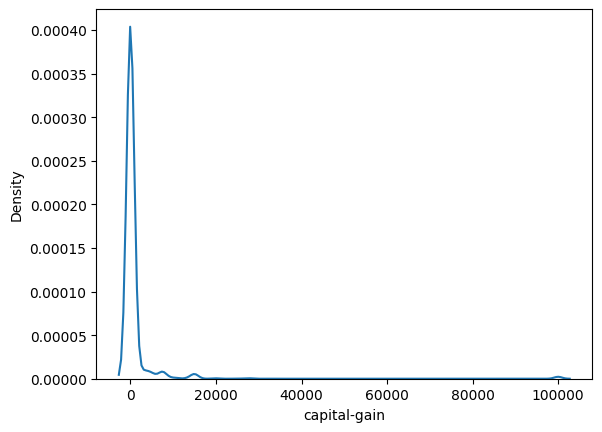

In [64]:
sns.kdeplot(data=X_train, x='capital-gain')

In [65]:
# Question : 5

x = 5
x = x / 100

min_range = X_train['capital-gain'].quantile(x)
max_range = X_train['capital-gain'].quantile(1-x)
print("min_range: ", min_range)
print("max_range: ", max_range)

min_range:  0.0
max_range:  5013.0


In [66]:
X_train['capital-gain'] = X_train['capital-gain'].clip(min_range, max_range)
X_test['capital-gain'] = X_test['capital-gain'].clip(min_range, max_range)

In [67]:
X_train['capital-gain'].describe()

,capital-gain
count,39073.000000
mean,355.222814
std,1223.385174
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,5013.000000


<Axes: xlabel='capital-gain', ylabel='Density'>

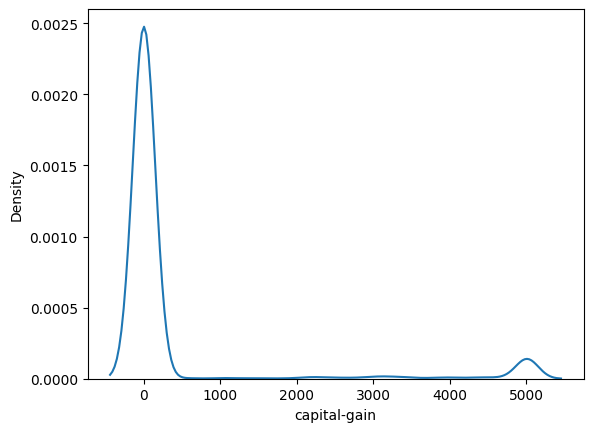

In [68]:
sns.kdeplot(data=X_train, x='capital-gain')

<Axes: xlabel='hours-per-week', ylabel='Density'>

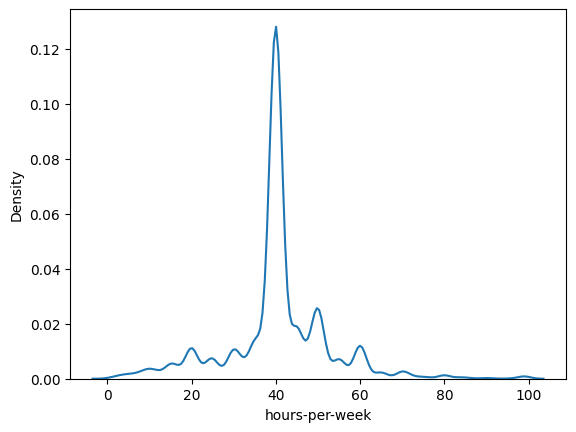

In [69]:
sns.kdeplot(data=X_train, x='hours-per-week')

In [70]:
# Question 06

features = ['hours-per-week', 'capital-gain']


robust = RobustScaler()
standard = StandardScaler()

robust_scaled = robust.fit_transform(X_train[features])
standard_scaled = standard.fit_transform(X_train[features])

**Q2 The Churning Machine**

**Question 07:**

Churn কলামে class imbalance রয়েছে, কারণ No এর সংখ্যা Yes এর তুলনায় অনেক বেশি। এর ফলে model বেশি সংখ্যক class (No) শেখার দিকে ঝুঁকে যেতে পারে।

যদি এই imbalance সমাধান না করা হয়, তাহলে model বেশিরভাগ customer-এর জন্য 'No' (Not Churn) predict করতে পারে এবং churn হওয়া customer-দের (Yes) সঠিকভাবে শনাক্ত করতে ব্যর্থ হতে পারে। ফলে accuracy ভালো দেখালেও churn prediction-এর ক্ষেত্রে model কার্যকর নাও হতে পারে।

**Question 08:**

TotalCharges column-এ কিছু blank/empty string (' ') value রয়েছে। সাধারণত যেসব customer-এর tenure = 0, তারা নতুন customer হওয়ায় তাদের এখনো কোনো charge জমা হয়নি, তাই TotalCharges ফাঁকা থাকে।

এই blank value-গুলোর কারণে Pandas column-টিকে numeric না ধরে object type হিসেবে পড়ে।

প্রয়োজনীয় preprocessing:

Blank string (' ') গুলোকে NaN এ convert করতে হবে।
এরপর column-টিকে numeric (float) type-এ convert করতে হবে।
প্রয়োজনে missing value impute বা remove করতে হবে।

**Question 09:**

Countplot with hue category অনুযায়ী observation-এর সংখ্যা দেখায় এবং churn distribution বিশ্লেষণে ব্যবহার হয়।
Barplot category অনুযায়ী কোনো numeric variable-এর average/median দেখায়।

এই dataset-এ:

**Countplot with hue** → Contract vs Churn

**Barplot** → Contract vs Average MonthlyCharges বা Tenure তুলনা করার জন্য।

In [71]:
# Question 10
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [73]:
df['TotalCharges'].dtype

dtype('O')

In [74]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype('float64')

In [75]:
df['TotalCharges'].dtype

dtype('float64')

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [77]:
# Question 11

cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'
]

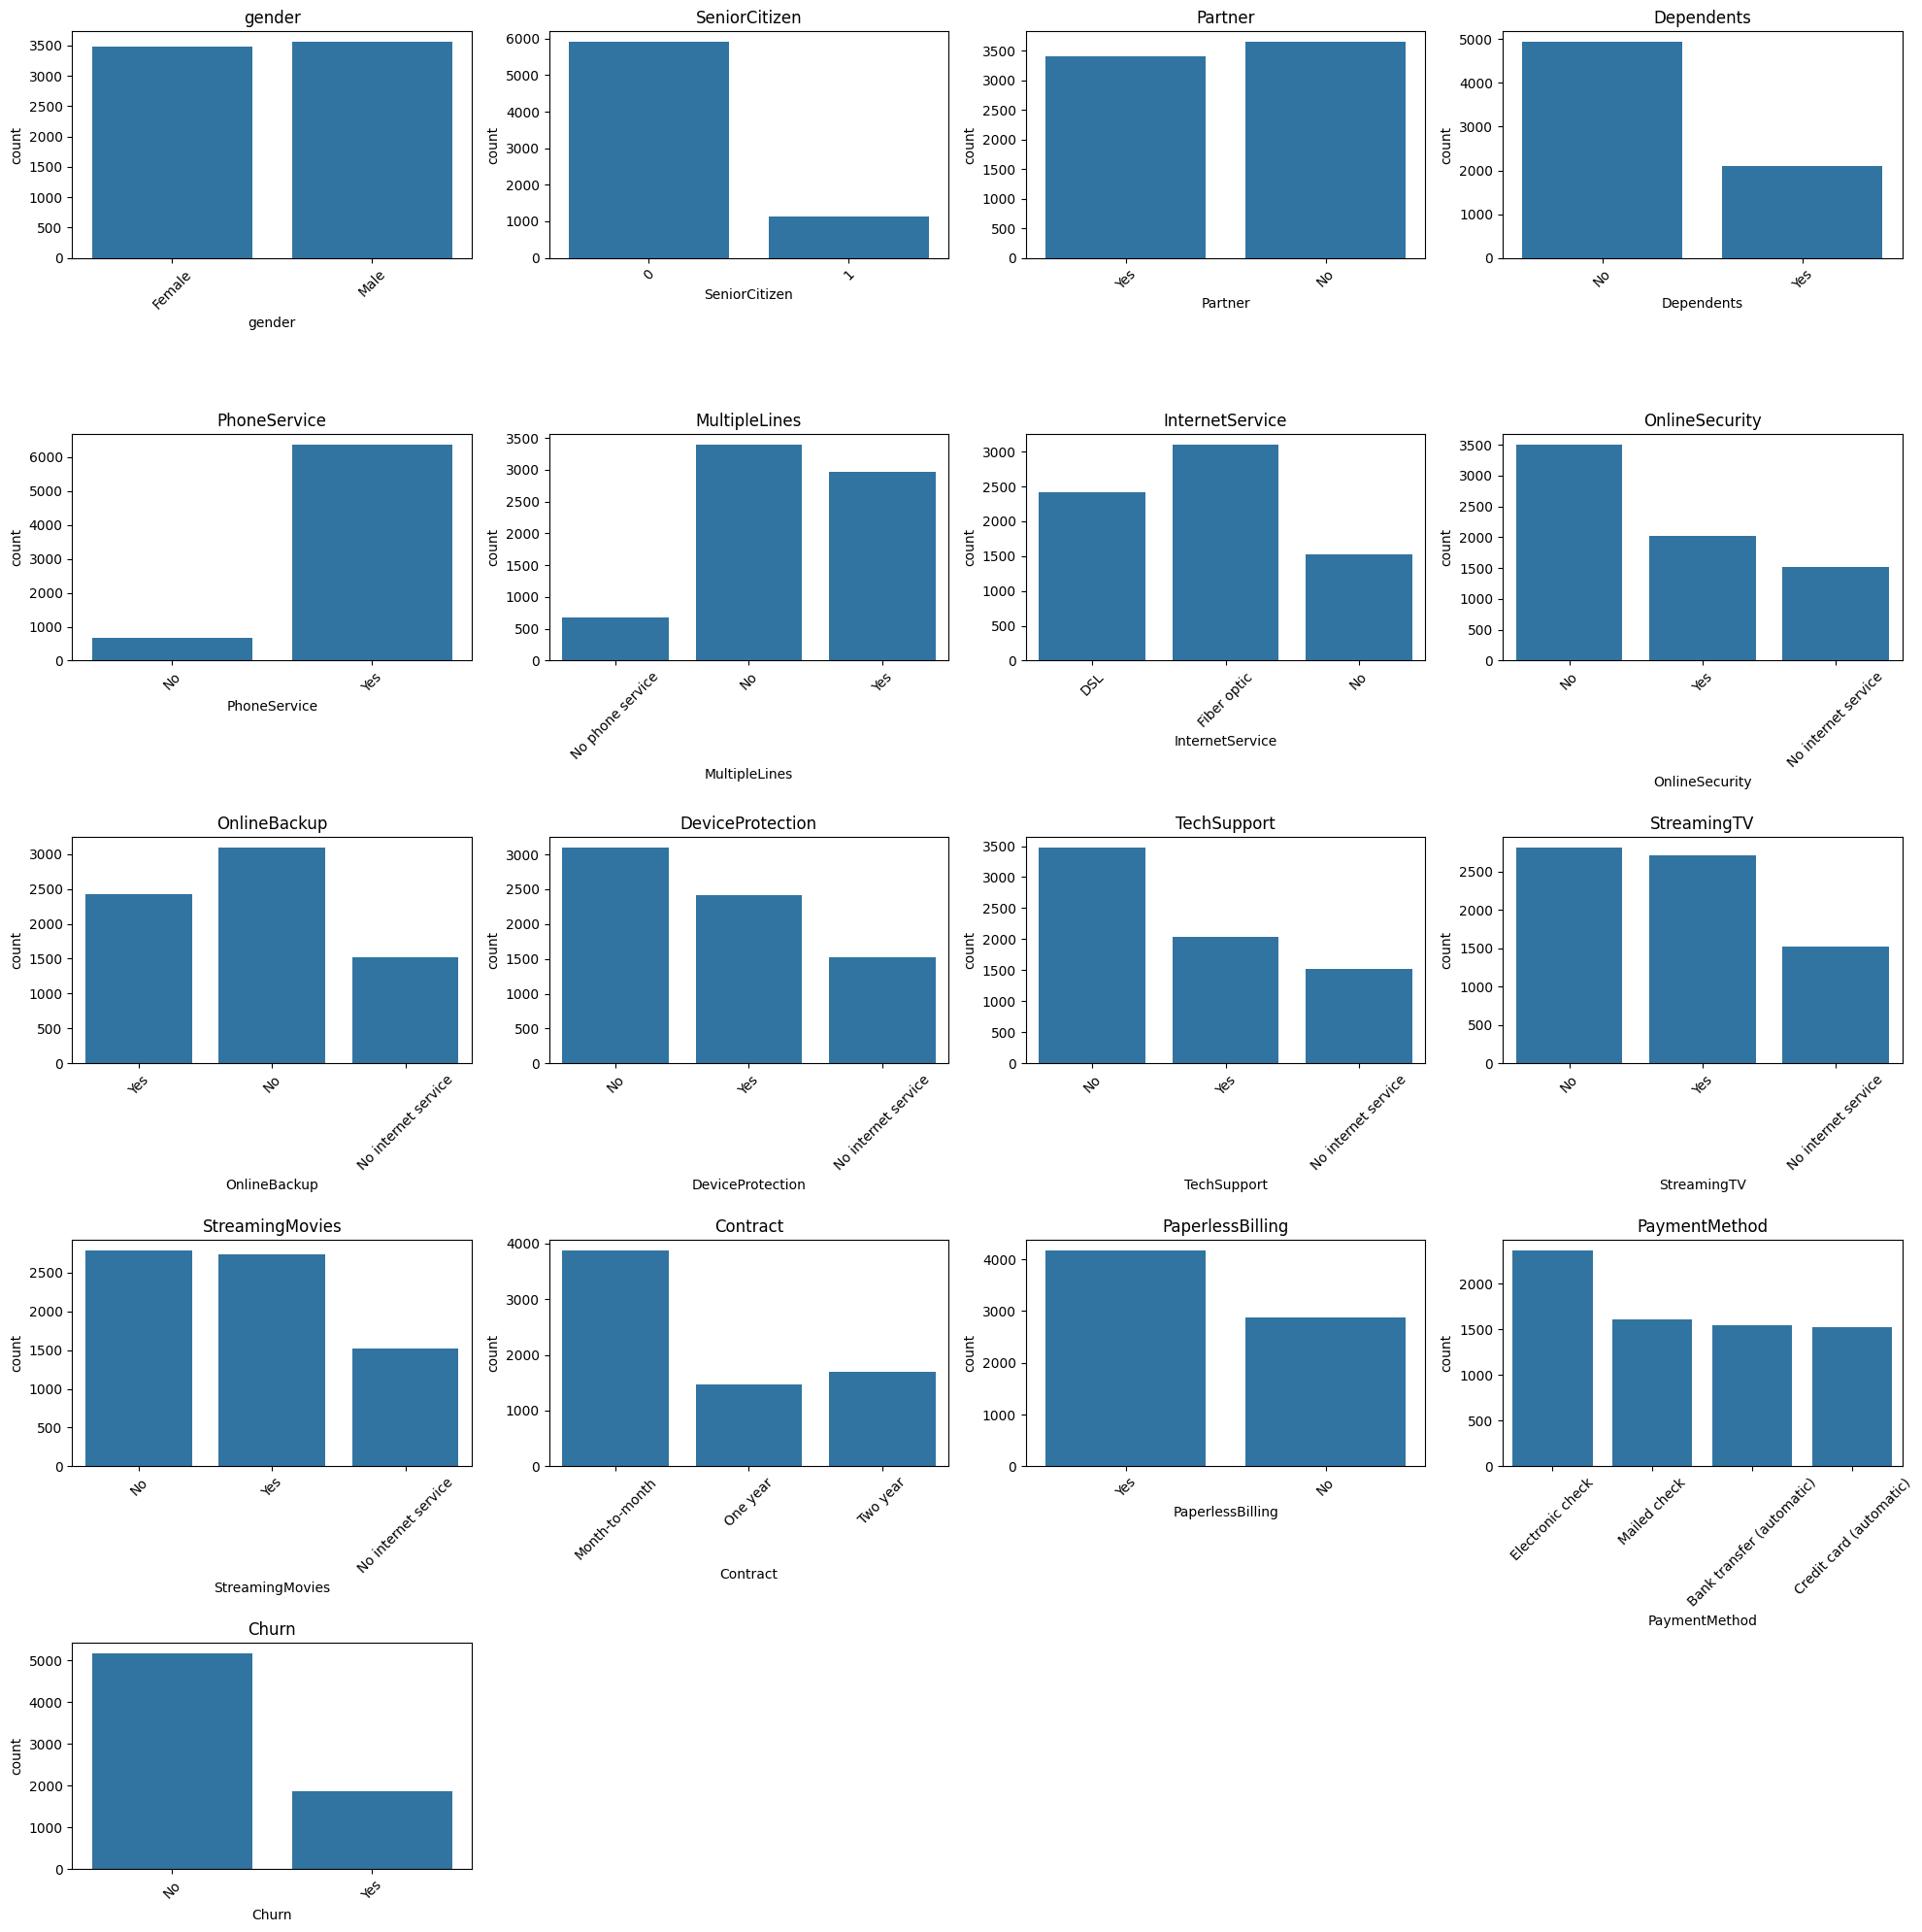

In [78]:
plt.figure(figsize=(20, 20))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(5, 4, i)
    sns.countplot(x=df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [79]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

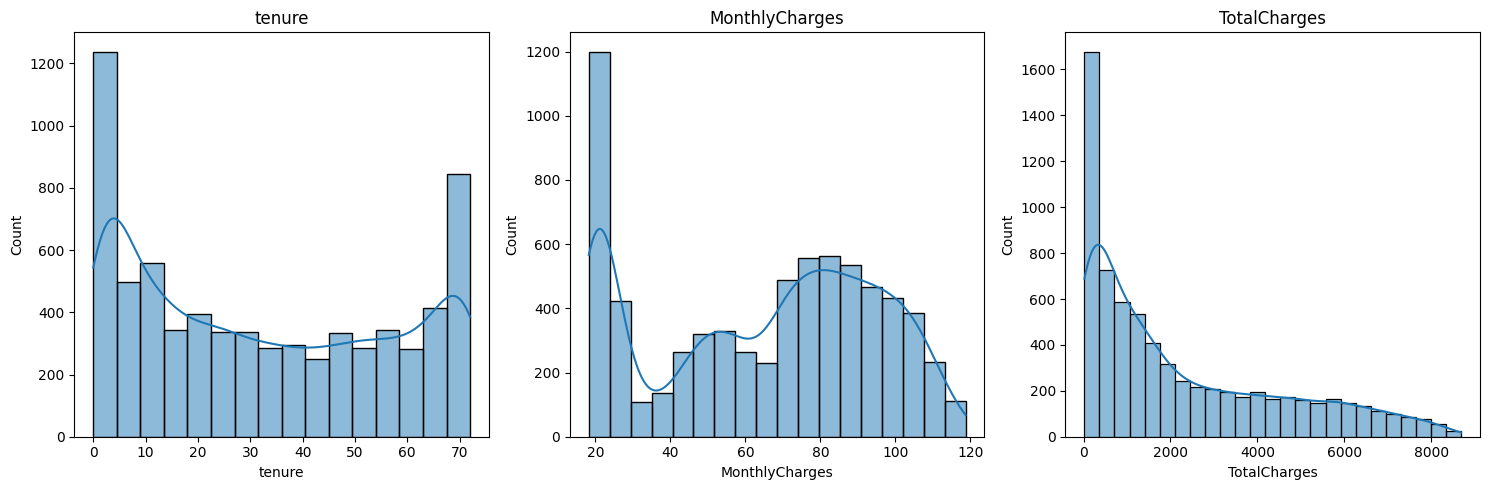

In [80]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: xlabel='Contract', ylabel='count'>

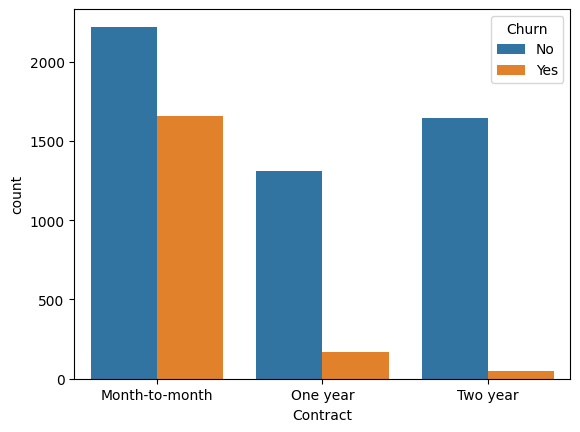

In [81]:
# Question 12

sns.countplot(x=df['Contract'], hue=df['Churn'])

<Axes: xlabel='tenure', ylabel='Density'>

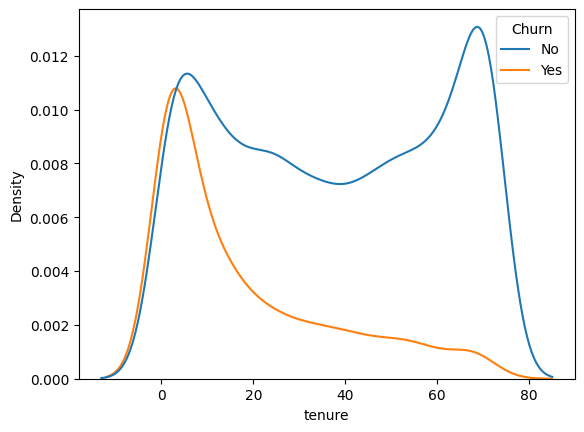

In [82]:
sns.kdeplot(data=df, x='tenure', hue='Churn')

**Contract vs Churn Countplot থেকে:**

যেসব গ্রাহকের Month-to-Month Contract রয়েছে, তাদের মধ্যে Churn-এর হার সবচেয়ে বেশি দেখা যায়।
অন্যদিকে One Year এবং Two Year Contract গ্রাহকদের Churn তুলনামূলকভাবে অনেক কম।

**Business Action:**
কোম্পানি Month-to-Month গ্রাহকদের জন্য দীর্ঘমেয়াদি চুক্তিতে (1 বা 2 বছর) যাওয়ার বিশেষ ছাড়, ডিসকাউন্ট বা লয়্যালটি অফার দিতে পারে, যা Churn কমাতে সাহায্য করবে।

**Tenure vs Churn KDE Plot থেকে:**

কম Tenure (নতুন গ্রাহক) থাকা গ্রাহকদের মধ্যে Churn-এর সম্ভাবনা বেশি।
বেশি সময় ধরে কোম্পানির সাথে থাকা গ্রাহকদের Churn করার প্রবণতা কম।

**Business Action:**
নতুন গ্রাহকদের জন্য onboarding support, welcome offers, customer care follow-up এবং loyalty benefits চালু করলে শুরুর দিকের Churn কমানো সম্ভব।

**Q3 Z-Scores & The Empirical Rule in the Wild**

**Question 13:**
BMI = 42

Z-score:

z=
6
42−30
	​

=2

অর্থাৎ BMI = 42 হলো Mean-এর 2 Standard Deviations উপরে।

**Question 14:**
1. Data Leakage-এর ঝুঁকি:
Train-test split-এর আগে outlier detection করলে test data-এর তথ্যও preprocessing-এ ব্যবহার হয়ে যায়, যা সঠিক machine learning practice নয়।

2. গুরুত্বপূর্ণ তথ্য হারানোর সম্ভাবনা:
charges-এর বড় মানগুলো বাস্তব ও গুরুত্বপূর্ণ হতে পারে (যেমন গুরুতর অসুস্থ রোগীর উচ্চ চিকিৎসা ব্যয়)। সব outlier মুছে ফেললে model গুরুত্বপূর্ণ pattern শিখতে পারবে না।

**Question 15:**

IQR এবং Z-score ভিন্ন পদ্ধতিতে outlier শনাক্ত করে, তাই একই data-তে ভিন্ন ফলাফল দিতে পারে।

**Z-score Method mean** ও **standard deviation** ব্যবহার করে, তাই এটি outlier এবং skewed data দ্বারা বেশি প্রভাবিত হয়।

IQR Method quartile (Q1, Q3) ব্যবহার করে, তাই এটি extreme value-এর প্রভাবে কম পরিবর্তিত হয়।

কখন কোনটি ব্যবহার করবে?

**Z-score Method** → Data প্রায় Normal Distribution হলে।

**IQR Method** → Data Skewed হলে বা অনেক outlier থাকলে।

তাই skewed data-র ক্ষেত্রে IQR সাধারণত বেশি নির্ভরযোগ্য, আর normal data-র ক্ষেত্রে Z-score ভালো কাজ করে।

In [83]:

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

df = pd.read_csv(url)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<Axes: xlabel='bmi', ylabel='Density'>

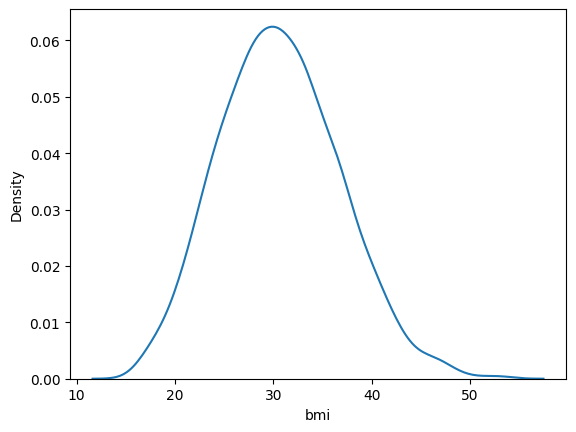

In [84]:
# Question 16
sns.kdeplot(data = df, x='bmi')

In [85]:
df['bmi'].skew()

np.float64(0.2840471105987448)

In [86]:
# Question 17

# (a) Identify outliers using the IQR method
charges_Q1 = df['charges'].quantile(0.25)
charges_Q3 = df['charges'].quantile(0.75)

IQR = charges_Q3 - charges_Q1

charges_min = charges_Q1 - 1.5 * IQR
charges_max = charges_Q3 + 1.5 * IQR

outliers = df[(df['charges'] < charges_min ) | (df['charges'] > charges_max)]

print(f"Number of outliers: {len(outliers)}")

Number of outliers: 139


In [87]:
# (b) Identify outliers using the Z-score method

mean_of_charges = df['charges'].mean()
std_of_charges = df['charges'].std()

df['zscore_charges'] = (df['charges'] - mean_of_charges) / std_of_charges

outliers_charges = df[abs(df['zscore_charges']) > 3]

print(f"Number of Outliers: {len(outliers_charges)}")

Number of Outliers: 7


IQR Method detected 139 outliers, whereas the Z-Score Method detected only 7 outliers. Therefore, the Z-Score Method is more conservative because it identifies far fewer observations as outliers than the IQR Method.

In [88]:
# Question 18

bins = [0, 18.5, 25, 30, float('inf')]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=bins,
    labels=labels,
    right=False
)

In [89]:
df['bmi_category'].value_counts()

,count
bmi_category,
Obese,707
Overweight,386
Normal,225
Underweight,20


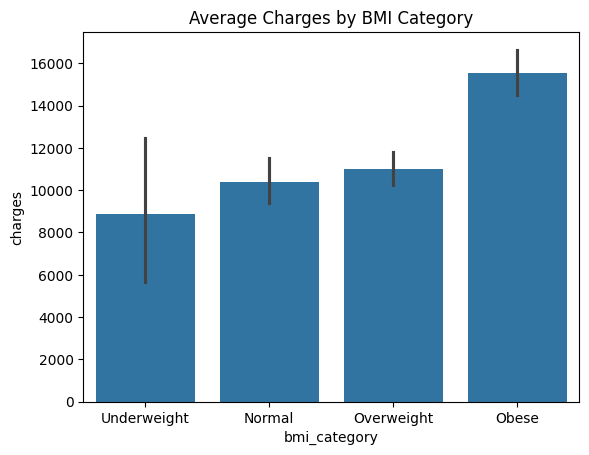

In [90]:
sns.barplot(
    data=df,
    x='bmi_category',
    y='charges',
    estimator= 'mean'
)
plt.title("Average Charges by BMI Category")
plt.show()

The barplot shows that average insurance charges increase as BMI category increases. The Obese group has the highest average charges, while the Underweight and Normal groups have lower average charges. This suggests that higher BMI is associated with higher medical expenses and insurance costs.

**Q4 The Big City Problem — Outlier Handling at Scale**

**Question 19:**

একটি 24 ঘণ্টার taxi trip NYC-এর জন্য অত্যন্ত অস্বাভাবিক, তাই এটিকে সরাসরি real trip ধরে নেওয়া উচিত নয়।

**Programmatically:**

trip_duration > 86400 বা >= 86400 হলে flag করা।
Pickup ও dropoff location, distance এবং route পরীক্ষা করা।
একই ধরনের আরও record আছে কিনা দেখা।

**Domain Knowledge:**

NYC-এর অধিকাংশ taxi trip কয়েক মিনিট থেকে কয়েক ঘণ্টার মধ্যে শেষ হয়।
২৪ ঘণ্টার trip বাস্তবে খুবই বিরল এবং সাধারণত data-entry error, GPS সমস্যা, বা timestamp recording issue নির্দেশ করে।

তাই 86,400-second trip-টিকে সম্ভাব্য outlier হিসেবে চিহ্নিত করা উচিত এবং অতিরিক্ত যাচাইয়ের পর remove বা handle করা উচিত।

**Question 20:**

না, test set থেকে outlier remove করা উচিত নয়।
কারণ test set বাস্তব-world data প্রতিনিধিত্ব করে, যেখানে outlier থাকতে পারে। Test set থেকে outlier সরিয়ে ফেললে model-এর performance অস্বাভাবিকভাবে ভালো দেখাতে পারে এবং বাস্তব পরিস্থিতি সঠিকভাবে মূল্যায়ন করা যাবে না।

In [91]:
# Question 21

df = pd.read_csv("train.csv", nrows = 20000)

df.head(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [92]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [93]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month

In [94]:
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,id3263883,1,2016-03-10 17:30:01,2016-03-10 17:46:48,1,-73.972504,40.756508,-73.980820,40.761787,N,1007,17,3,3
19996,id2600174,2,2016-02-08 19:54:02,2016-02-08 20:11:58,1,-74.007507,40.726292,-73.967369,40.788616,N,1076,19,0,2
19997,id3433340,1,2016-03-17 11:46:18,2016-03-17 11:57:11,1,-73.984177,40.761471,-73.990601,40.751087,N,653,11,3,3
19998,id2596866,1,2016-06-01 17:22:09,2016-06-01 17:38:44,1,-73.995407,40.749489,-73.984955,40.769161,N,995,17,2,6


In [95]:
invalid_trips = [
    (df['trip_duration'] <= 0) |
    (df['trip_duration'] > 86400)      # 24h = 86400s
]

print(f"Number of impossible trip durations: {len(invalid_trips)}")

Number of impossible trip durations: 1


In [96]:
# Question 22

Q1 = df['trip_duration'].quantile(0.25)
Q3 = df['trip_duration'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

trip_duration_outliers = (df['trip_duration'] < lower_bound) | (df['trip_duration'] > upper_bound)

In [97]:
number_of_outliers = len(trip_duration_outliers)

percentage = (number_of_outliers / len(df)) * 100

print("Number of outliers: ", number_of_outliers)
print("Percentage of data: ", round(percentage, 2), "%")

Number of outliers:  20000
Percentage of data:  100.0 %


In [98]:
outlier_clean = (df['trip_duration'] >= lower_bound) | (df['trip_duration'] <= upper_bound)

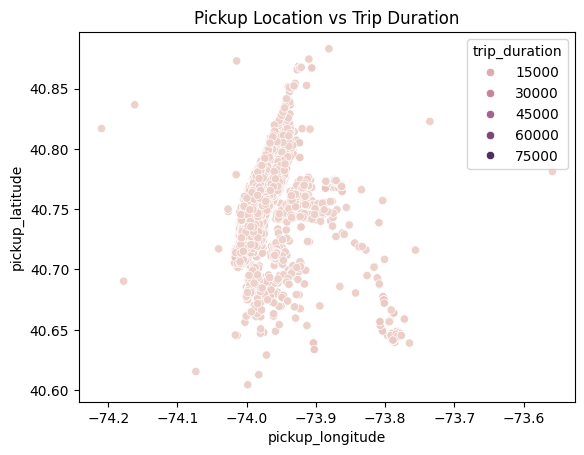

In [99]:
# Question 23

sns.scatterplot(data=df, x='pickup_longitude', y='pickup_latitude', hue='trip_duration')

plt.title("Pickup Location vs Trip Duration")
plt.show()

**Q5: Happiness by the Numbers — Full EDA Story**

**Question 24:**

GDP per capita সাধারণত highly right-skewed হয়, অর্থাৎ কিছু দেশের GDP খুব বেশি থাকে এবং বেশিরভাগ দেশের GDP তুলনামূলক কম থাকে।

Log transformation এই skewness কমায়, extreme value-এর প্রভাব কম করে এবং distribution-কে আরও symmetric বা normal-এর কাছাকাছি নিয়ে আসে।

তাই GDP per capita-কে log-transform করা হয় যাতে data-এর right-skewness কমে, variance স্থিতিশীল হয় এবং analysis ও modeling আরও কার্যকর হয়।

**Question 25:**

হ্যাঁ, এই তিনটি feature-এর Happiness Score-এর উপর ইতিবাচক প্রভাব থাকার সম্ভাবনা বেশি।

Social Support: মানুষ প্রয়োজনে সাহায্য পেলে সাধারণত বেশি সন্তুষ্ট ও সুখী থাকে।

Healthy Life Expectancy: দীর্ঘ ও সুস্থ জীবন মানুষের জীবনমান ও সুখ বৃদ্ধি করে।

Freedom to Make Life Choices: নিজের সিদ্ধান্ত নিজে নিতে পারলে মানুষ বেশি স্বাধীন ও সন্তুষ্ট বোধ করে।

**Question 26:**

এই সিদ্ধান্ত পুরোপুরি সঠিক নয়। Scatterplot শুধুমাত্র correlation (সম্পর্ক) দেখায়, causation (কারণ-ফল সম্পর্ক) প্রমাণ করে না।

উচ্চ GDP এবং উচ্চ happiness একসাথে দেখা গেলেও এর অর্থ এই নয় যে GDP-ই সরাসরি happiness-এর কারণ। Happiness-এর উপর আরও অনেক বিষয় প্রভাব ফেলে, যেমন:

Social Support

Healthy Life Expectancy

Freedom to Make Life Choices

রাজনৈতিক ও সামাজিক স্থিতিশীলতা

তাই scatterplot থেকে বলা যায় যে GDP এবং Happiness-এর মধ্যে একটি positive relationship আছে, কিন্তু শুধুমাত্র এই graph দেখে GDP happiness-এর কারণ—এমন সিদ্ধান্ত নেওয়া ঠিক নয়।

In [100]:
# Question 27

df = pd.read_csv("world-happiness-report-2021.csv")
df.head(5)

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


In [101]:
top_10 = df.nlargest(10, 'Ladder score')
bottom_10 = df.nsmallest(10, 'Ladder score')


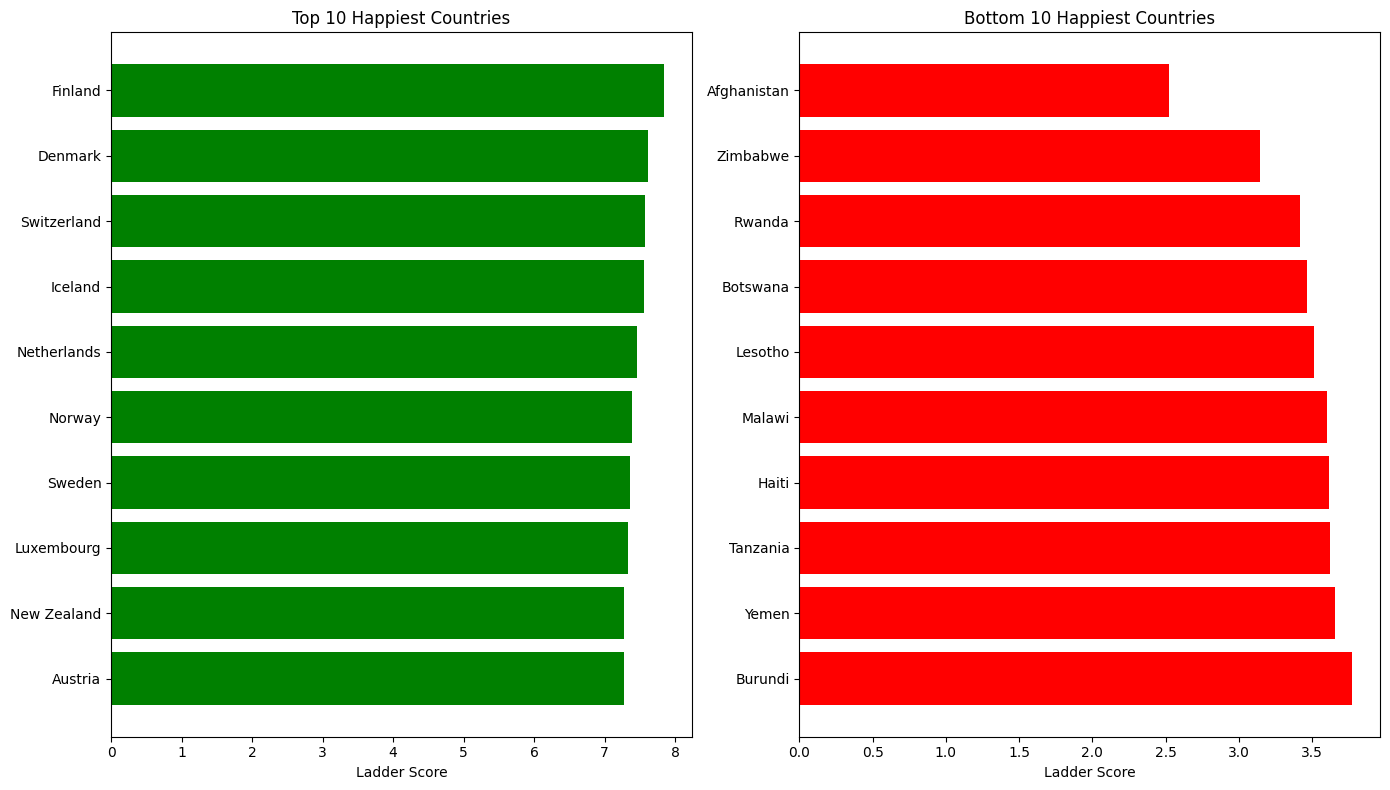

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Top 10
axes[0].barh(
    top_10['Country name'],
    top_10['Ladder score'],
    color='green'
)
axes[0].set_title('Top 10 Happiest Countries')
axes[0].set_xlabel('Ladder Score')
axes[0].invert_yaxis()


# Bottom 10
axes[1].barh(
    bottom_10['Country name'],
    bottom_10['Ladder score'],
    color='red'
)
axes[1].set_title('Bottom 10 Happiest Countries')
axes[1].set_xlabel('Ladder Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

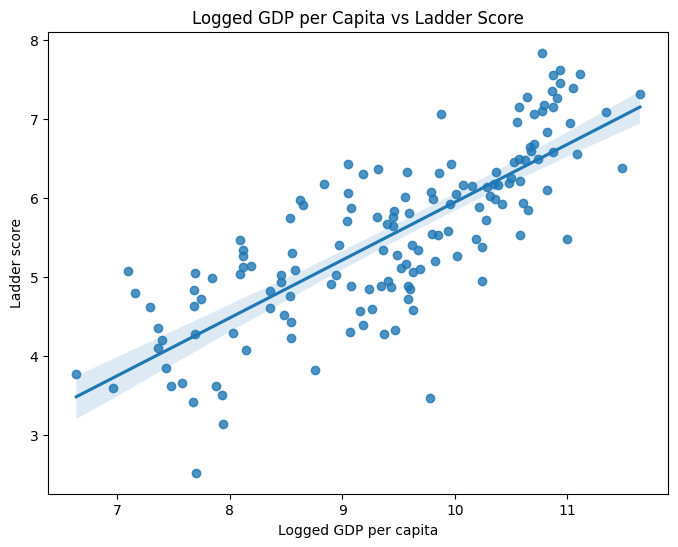

In [103]:
# Question 28

plt.figure(figsize=(8, 6))

sns.regplot(data=df, x='Logged GDP per capita', y='Ladder score')

plt.title("Logged GDP per Capita vs Ladder Score")
plt.xlabel("Logged GDP per capita")
plt.ylabel("Ladder score")
plt.show()

In [104]:
# Question 29

regional_mean = df.groupby('Regional indicator').mean(numeric_only=True)
print(regional_mean)

                                    Ladder score  \
Regional indicator                                 
Central and Eastern Europe              5.984765   
Commonwealth of Independent States      5.467000   
East Asia                               5.810333   
Latin America and Caribbean             5.908050   
Middle East and North Africa            5.219765   
North America and ANZ                   7.128500   
South Asia                              4.441857   
Southeast Asia                          5.407556   
Sub-Saharan Africa                      4.494472   
Western Europe                          6.914905   

                                    Standard error of ladder score  \
Regional indicator                                                   
Central and Eastern Europe                                0.048471   
Commonwealth of Independent States                        0.046750   
East Asia                                                 0.040000   
Latin America and Caribbe

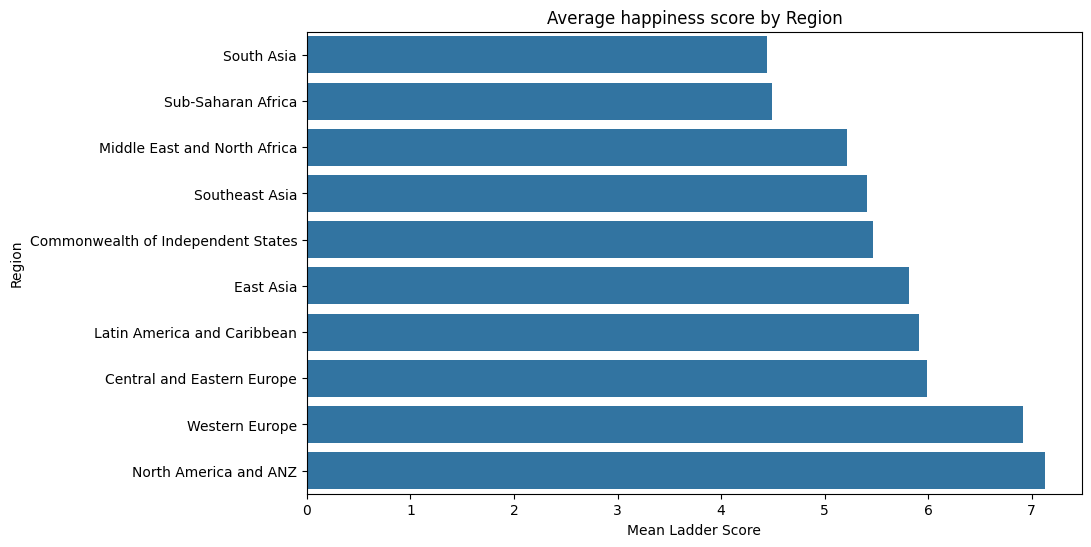

In [105]:
region_happiness = (df.groupby('Regional indicator')['Ladder score'].mean().sort_values(ascending=True).reset_index())

plt.figure(figsize=(10, 6))

sns.barplot(data= region_happiness, x = 'Ladder score', y = 'Regional indicator')
plt.title("Average happiness score by Region")
plt.xlabel("Mean Ladder Score")
plt.ylabel("Region")
plt.show()

In [106]:
region_variance = (
    df.groupby('Regional indicator')['Ladder score']
      .var()
      .sort_values(ascending=False)
)

print(region_variance)

Regional indicator
Middle East and North Africa          0.998519
South Asia                            0.986966
Latin America and Caribbean           0.480896
Western Europe                        0.431018
Sub-Saharan Africa                    0.428884
Southeast Asia                        0.367565
Central and Eastern Europe            0.243370
East Asia                             0.193524
Commonwealth of Independent States    0.191946
North America and ANZ                 0.019060
Name: Ladder score, dtype: float64


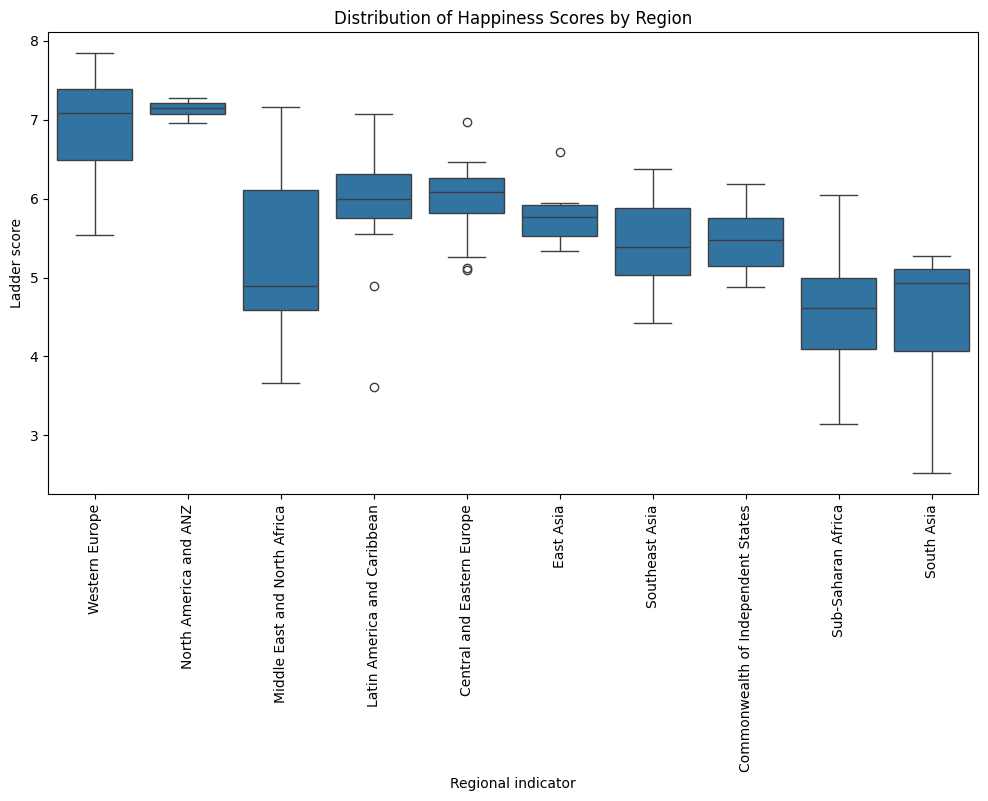

In [107]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Regional indicator', y= 'Ladder score')

plt.xticks(rotation=90)
plt.title("Distribution of Happiness Scores by Region")
plt.show()

**SURPRISE BONUS CHALLENGE**

In [108]:
df = pd.read_csv("world-happiness-report-2021.csv")
df.head(5)

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


In [109]:
df.drop(['Country name'], axis=1, inplace=True)

In [110]:
df.isnull().sum()

,0
Regional indicator,0
Ladder score,0
Standard error of ladder score,0
upperwhisker,0
lowerwhisker,0
Logged GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0


In [111]:
X = df.drop(['Ladder score'], axis=1)

X

,Regional indicator,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Western Europe,0.032,7.904,7.780,10.775,0.954,72.000,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Western Europe,0.035,7.687,7.552,10.933,0.954,72.700,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Western Europe,0.036,7.643,7.500,11.117,0.942,74.400,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Western Europe,0.059,7.670,7.438,10.878,0.983,73.000,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Western Europe,0.027,7.518,7.410,10.932,0.942,72.400,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,Sub-Saharan Africa,0.120,3.748,3.276,7.926,0.787,48.700,0.715,-0.131,0.915,2.43,0.451,0.731,0.007,0.405,0.103,0.015,1.800
145,Sub-Saharan Africa,0.074,3.611,3.322,9.782,0.784,59.269,0.824,-0.246,0.801,2.43,1.099,0.724,0.340,0.539,0.027,0.088,0.648
146,Sub-Saharan Africa,0.068,3.548,3.282,7.676,0.552,61.400,0.897,0.061,0.167,2.43,0.364,0.202,0.407,0.627,0.227,0.493,1.095
147,Sub-Saharan Africa,0.058,3.259,3.030,7.943,0.750,56.201,0.677,-0.047,0.821,2.43,0.457,0.649,0.243,0.359,0.157,0.075,1.205


In [112]:
y = df['Ladder score']

y

,Ladder score
0,7.842
1,7.620
2,7.571
3,7.554
4,7.464
...,...
144,3.512
145,3.467
146,3.415
147,3.145


In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [114]:
X_train

,Regional indicator,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
22,Western Europe,0.044,6.688,6.516,10.674,0.931,72.200,0.927,0.133,0.653,2.43,1.411,1.055,0.747,0.664,0.275,0.183,2.268
15,Latin America and Caribbean,0.056,7.179,6.960,9.880,0.891,71.400,0.934,-0.126,0.809,2.43,1.134,0.966,0.722,0.673,0.105,0.083,3.387
65,Latin America and Caribbean,0.057,5.875,5.653,9.313,0.821,68.800,0.842,-0.124,0.843,2.43,0.935,0.806,0.640,0.560,0.107,0.062,2.653
11,Middle East and North Africa,0.034,7.224,7.090,10.575,0.939,73.503,0.800,0.031,0.753,2.43,1.376,1.074,0.788,0.509,0.208,0.119,3.083
42,Latin America and Caribbean,0.046,6.262,6.081,10.071,0.882,70.000,0.742,-0.044,0.830,2.43,1.200,0.946,0.678,0.438,0.159,0.070,2.682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Central and Eastern Europe,0.054,5.686,5.475,9.940,0.858,68.699,0.708,-0.034,0.812,2.43,1.155,0.891,0.637,0.397,0.166,0.081,2.254
106,Latin America and Caribbean,0.064,5.017,4.767,9.073,0.861,66.700,0.615,-0.169,0.827,2.43,0.852,0.897,0.574,0.284,0.078,0.072,2.135
14,Western Europe,0.040,7.164,7.006,11.342,0.947,72.400,0.879,0.077,0.363,2.43,1.644,1.092,0.753,0.606,0.238,0.367,2.384
92,Central and Eastern Europe,0.059,5.234,5.001,9.520,0.697,68.999,0.785,-0.030,0.901,2.43,1.008,0.529,0.646,0.491,0.168,0.024,2.250


In [115]:
X_test

,Regional indicator,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
73,Western Europe,0.051,5.636,5.435,10.576,0.820,73.898,0.795,0.012,0.626,2.43,1.377,0.806,0.801,0.503,0.196,0.200,1.653
18,North America and ANZ,0.049,7.047,6.856,11.023,0.920,68.200,0.837,0.098,0.698,2.43,1.533,1.030,0.621,0.554,0.252,0.154,2.807
117,Middle East and North Africa,0.055,4.828,4.614,9.584,0.710,66.300,0.608,0.218,0.714,2.43,1.030,0.557,0.561,0.275,0.330,0.144,1.823
78,Southeast Asia,0.039,5.488,5.334,8.973,0.850,68.034,0.940,-0.098,0.796,2.43,0.817,0.873,0.616,0.679,0.124,0.091,2.211
76,East Asia,0.049,5.573,5.380,11.000,0.836,76.820,0.717,0.067,0.403,2.43,1.525,0.841,0.893,0.408,0.232,0.342,1.236
31,Southeast Asia,0.043,6.460,6.293,11.488,0.915,76.953,0.927,-0.018,0.082,2.43,1.695,1.019,0.897,0.664,0.176,0.547,1.379
64,Commonwealth of Independent States,0.046,5.856,5.677,9.454,0.857,65.699,0.822,-0.079,0.918,2.43,0.985,0.888,0.542,0.536,0.137,0.013,2.665
140,Middle East and North Africa,0.070,3.794,3.521,7.578,0.832,57.122,0.602,-0.147,0.800,2.43,0.329,0.831,0.272,0.268,0.092,0.089,1.776
68,Latin America and Caribbean,0.053,5.819,5.613,9.046,0.810,63.901,0.875,-0.077,0.839,2.43,0.842,0.782,0.486,0.600,0.138,0.064,2.805
82,Sub-Saharan Africa,0.097,5.533,5.151,8.117,0.636,58.221,0.695,-0.068,0.745,2.43,0.518,0.392,0.307,0.381,0.144,0.124,3.476


In [116]:
X_train.isnull().sum()

,0
Regional indicator,0
Standard error of ladder score,0
upperwhisker,0
lowerwhisker,0
Logged GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


In [117]:
X_train.isnull().sum()

,0
Regional indicator,0
Standard error of ladder score,0
upperwhisker,0
lowerwhisker,0
Logged GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


In [118]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119 entries, 22 to 102
Data columns (total 18 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Regional indicator                          119 non-null    object 
 1   Standard error of ladder score              119 non-null    float64
 2   upperwhisker                                119 non-null    float64
 3   lowerwhisker                                119 non-null    float64
 4   Logged GDP per capita                       119 non-null    float64
 5   Social support                              119 non-null    float64
 6   Healthy life expectancy                     119 non-null    float64
 7   Freedom to make life choices                119 non-null    float64
 8   Generosity                                  119 non-null    float64
 9   Perceptions of corruption                   119 non-null    float64
 10  Ladder score in Dy

In [119]:
# Z-score

mean_of_L_GDP_perCapita = X_train['Logged GDP per capita'].mean()
std_of_L_GDP_perCapita = X_train['Logged GDP per capita'].std()

X_train['zscore_LGDP_perCapita'] = (X_train['Logged GDP per capita'] - mean_of_L_GDP_perCapita) / std_of_L_GDP_perCapita

outliers_L_GDP_perCapita = X_train[abs(X_train['zscore_LGDP_perCapita']) > 3]
print(len(outliers_L_GDP_perCapita))

0


In [120]:
mean_of_Social_support = X_train['Social support'].mean()
std_of_Social_support = X_train['Social support'].std()

X_train['zscroe_Social_support'] = (X_train['Social support'] - mean_of_Social_support) / std_of_Social_support

outliers_Social_support = X_train[abs(X_train['zscroe_Social_support']) > 3]
print(len(outliers_Social_support))

0


In [121]:
mean_of_Healthy_lifeExpectancy = X_train['Healthy life expectancy'].mean()
std_of_Healthy_lifeExpectancy = X_train['Healthy life expectancy'].std()

X_train['zscore_Healthy_lifeExpectancy'] = (X_train['Healthy life expectancy'] - mean_of_Healthy_lifeExpectancy) / std_of_Healthy_lifeExpectancy

outliers_Healthy_lifeExpectancy = X_train[abs(X_train['zscore_Healthy_lifeExpectancy']) > 3]

print(len(outliers_Healthy_lifeExpectancy))

0


In [122]:
mean_of_FreedomToMakeLifeChoices = X_train['Freedom to make life choices'].mean()
std_of_FreedomToMakeLifeChoices = X_train['Freedom to make life choices'].std()

X_train['zscore_FreedomToMakeLifeChoices'] = (X_train['Freedom to make life choices'] - mean_of_FreedomToMakeLifeChoices) / std_of_FreedomToMakeLifeChoices

outliers_FreedomToMakeLifeChoices = X_train[abs(X_train['zscore_FreedomToMakeLifeChoices']) > 3]
print(len(outliers_FreedomToMakeLifeChoices))

1


In [123]:
mean_of_Generosity = X_train['Generosity'].mean()
std_of_Generosity = X_train['Generosity'].std()

X_train['zscore_Generosity'] = (X_train['Generosity'] - mean_of_Generosity) / std_of_Generosity

outliers_Generosity = X_train[abs(X_train['zscore_Generosity']) > 3]
print(len(outliers_Generosity))

2


In [124]:
mean_of_Perceptions_ofCorruption = X_train['Perceptions of corruption'].mean()
std_of_Perceptions_ofCorruption = X_train['Perceptions of corruption'].std()

X_train['zscore_Perceptions_ofCorruption'] = (X_train['Perceptions of corruption'] - mean_of_Perceptions_ofCorruption) / std_of_Perceptions_ofCorruption

outliers_Perceptions_ofCorruption = X_train[abs(X_train['zscore_Perceptions_ofCorruption']) > 3]
print(len(outliers_Perceptions_ofCorruption))

3


In [125]:
# IQR

Q1 = X_train['Logged GDP per capita'].quantile(0.25)
Q3 = X_train['Logged GDP per capita'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Logged_GDP_outlier_IQR = X_train[(X_train['Logged GDP per capita'] < lower_bound) | (X_train['Logged GDP per capita'] > upper_bound)]

print(len(Logged_GDP_outlier_IQR))

0


In [126]:
# IQR

Q1 = X_train['Social support'].quantile(0.25)
Q3 = X_train['Social support'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Social_support_outlier_IQR = X_train[(X_train['Social support'] < lower_bound) | (X_train['Social support'] > upper_bound)]

print(len(Social_support_outlier_IQR))

3


In [127]:
# IQR

Q1 = X_train['Healthy life expectancy'].quantile(0.25)
Q3 = X_train['Healthy life expectancy'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Healthy_life_expectancy_outlier_IQR = X_train[(X_train['Healthy life expectancy'] < lower_bound) | (X_train['Healthy life expectancy'] > upper_bound)]

print(len(Healthy_life_expectancy_outlier_IQR))

0


In [128]:
# IQR

Q1 = X_train['Freedom to make life choices'].quantile(0.25)
Q3 = X_train['Freedom to make life choices'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

FreedomTo_make_life_choices_outlier_IQR = X_train[(X_train['Freedom to make life choices'] < lower_bound) | (X_train['Freedom to make life choices'] > upper_bound)]

print(len(FreedomTo_make_life_choices_outlier_IQR))

2


In [129]:
# IQR

Q1 = X_train['Generosity'].quantile(0.25)
Q3 = X_train['Generosity'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Generosity_outlier_IQR = X_train[(X_train['Generosity'] < lower_bound) | (X_train['Generosity'] > upper_bound)]

print(len(Generosity_outlier_IQR))

4


In [130]:
# IQR

Q1 = X_train['Perceptions of corruption'].quantile(0.25)
Q3 = X_train['Perceptions of corruption'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Perceptions_of_corruption_outlier_IQR = X_train[(X_train['Perceptions of corruption'] < lower_bound) | (X_train['Perceptions of corruption'] > upper_bound)]

print(len(Perceptions_of_corruption_outlier_IQR))

10


In [131]:
X_train.drop(['Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices',
             'Generosity', 'Perceptions of corruption'], axis=1, inplace=True)

In [132]:
X_train

,Regional indicator,Standard error of ladder score,upperwhisker,lowerwhisker,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,zscore_LGDP_perCapita,zscroe_Social_support,zscore_Healthy_lifeExpectancy,zscore_FreedomToMakeLifeChoices,zscore_Generosity,zscore_Perceptions_ofCorruption
22,Western Europe,0.044,6.688,6.516,2.43,1.411,1.055,0.747,0.664,0.275,0.183,2.268,1.087056,0.993478,1.121358,1.141797,0.888904,-0.405587
15,Latin America and Caribbean,0.056,7.179,6.960,2.43,1.134,0.966,0.722,0.673,0.105,0.083,3.387,0.407873,0.660430,0.998767,1.201937,-0.746830,0.469915
65,Latin America and Caribbean,0.057,5.875,5.653,2.43,0.935,0.806,0.640,0.560,0.107,0.062,2.653,-0.077137,0.077595,0.600347,0.411523,-0.734199,0.660729
11,Middle East and North Africa,0.034,7.224,7.090,2.43,1.376,1.074,0.788,0.509,0.208,0.119,3.083,1.002372,1.060088,1.321028,0.050682,0.244715,0.155632
42,Latin America and Caribbean,0.046,6.262,6.081,2.43,1.200,0.946,0.678,0.438,0.159,0.070,2.682,0.571253,0.585494,0.784233,-0.447622,-0.228953,0.587770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Central and Eastern Europe,0.054,5.686,5.475,2.43,1.155,0.891,0.637,0.397,0.166,0.081,2.254,0.459196,0.385665,0.584870,-0.739731,-0.165797,0.486751
106,Latin America and Caribbean,0.064,5.017,4.767,2.43,0.852,0.897,0.574,0.284,0.078,0.072,2.135,-0.282431,0.410643,0.278545,-1.538737,-1.018400,0.570934
14,Western Europe,0.040,7.164,7.006,2.43,1.644,1.092,0.753,0.606,0.238,0.367,2.384,1.658460,1.126697,1.152006,0.729407,0.535232,-2.033121
92,Central and Eastern Europe,0.059,5.234,5.001,2.43,1.008,0.529,0.646,0.491,0.168,0.024,2.250,0.099930,-0.954856,0.630841,-0.078189,-0.140535,0.986236
